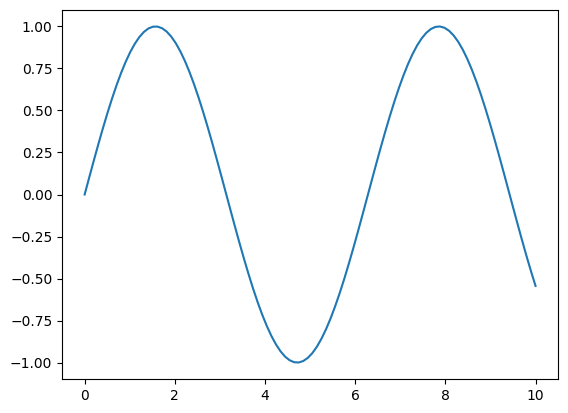

In [4]:
%matplotlib inline  
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.show()  

In [8]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l
n = 10000
a = torch.ones([n])
b = torch.ones([n])
class Timer:  #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.19466 sec'

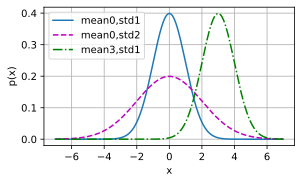

In [9]:
%matplotlib inline  
import math
import time
import numpy as np
import torch
from d2l import torch as d2l
from matplotlib.pyplot import legend


def normal(x,mu,sigma):
    p=1/math.sqrt(2*math.pi*sigma**2)
    return p* np.exp(-0.5/sigma**2 * (x-mu)**2)
x=np.arange(-7,7,0.01)

params=[(0,1),(0,2),(3,1)]
d2l.plot(x,[normal(x,mu,sigma) for mu,sigma in params],xlabel='x',
         ylabel='p(x)',figsize=(4.5,2.5),
         legend=[f'mean{mu},std{sigma}'for mu,sigma in params])



features: tensor([-0.6975, -0.1861]) 
label: tensor([3.4343])


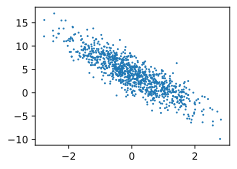

In [11]:
import torch
from d2l import torch as d2l


def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)

print('features:', features[0],'\nlabel:', labels[0])
d2l.set_figsize()
d2l.plt.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), 1);

In [19]:
%matplotlib inline  
import math
import time
import numpy as np
import torch
import random
from d2l import torch as d2l
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break
    
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
def linreg(X, w, b):  #@save
    """线性回归模型"""
    return torch.matmul(X, w) + b
def squared_loss(y_hat, y):  #@save
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

tensor([[ 0.4057,  0.5014],
        [-0.4766, -0.2229],
        [ 0.1271,  1.4985],
        [ 0.2023,  0.4851],
        [-0.2923,  1.5171],
        [ 0.9054,  0.1263],
        [ 0.2978, -0.0074],
        [ 0.2928,  0.1723],
        [-0.8548, -1.3557],
        [ 1.0873,  0.5629]]) 
 tensor([[ 3.3137],
        [ 3.9917],
        [-0.6284],
        [ 2.9416],
        [-1.5255],
        [ 5.5908],
        [ 4.8136],
        [ 4.1842],
        [ 7.1014],
        [ 4.4693]])
epoch 1, loss 0.050294
epoch 2, loss 0.000213
epoch 3, loss 0.000049
w的估计误差: tensor([ 0.0002, -0.0005], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0007], grad_fn=<RsubBackward1>)
